**NOTICE:**  
The U.S. Army Corps of Engineers, Risk Management Center (USACE-RMC) makes no guarantees about the results, or appropriateness of outputs, obtained from Numerics.

# 09. Machine Learning with Numerics
This notebook explores machine learning capabilities in Numerics.

## What You'll Learn

- K-Means Clustering (unsupervised)
- Random Forest (classification and regression)
- Gaussian Mixture Models (probabilistic clustering)
- K-Nearest Neighbors (classification and regression)
- Decision Trees (interpretable models)
- Performance comparisons with scikit-learn

## Algorithms Covered

| Algorithm | Type | Use Case |
|-----------|------|----------|
| **K-Means** | Clustering | Fast, hard cluster assignments |
| **Random Forest** | Ensemble | Classification/regression with feature importance |
| **GMM** | Clustering | Probabilistic, soft assignments, non-spherical clusters |
| **KNN** | Instance-based | Simple classification/regression |
| **Decision Trees** | Tree-based | Interpretable, handles non-linearity |


## Setup

In [22]:
import pythonnet
pythonnet.load("coreclr")

import clr
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

# Optional sklearn imports (for datasets + benchmarks)
from sklearn.datasets import load_iris, load_wine, load_breast_cancer, load_diabetes, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    mean_squared_error, r2_score, adjusted_rand_score
)
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans as SKLearnKMeans
from scipy.optimize import linear_sum_assignment

from System import Array, Double, String
from System.Collections.Generic import List

# Load Numerics DLL
dll_path = Path(r"C:\GIT\Numerics\Numerics\bin\Debug\net8.0\Numerics.dll")
clr.AddReference(str(dll_path))

from Numerics.MachineLearning import KMeans, RandomForest, GaussianMixtureModel, KNearestNeighbors, DecisionTree
from Numerics.Mathematics.LinearAlgebra import Matrix, Vector
from helper_functions import convert_to_dotnet_array, convert_to_dotnet_2d_array


print("✓ Setup complete")

✓ Setup complete


## Helper Functions
We define a helper function to time our methods.

In [23]:
def timed_fit(train_callable):
    t0 = time.perf_counter()
    train_callable()
    return (time.perf_counter() - t0) * 1000.0  # ms

# containers for final summary table/dashboard
results = []
print("✓ Helpers ready")

✓ Helpers ready


## 1: K-Means Clustering
K-Means is an unsupervised learning algorithm that partitions data into K clusters.  It works best when clusters are roughly compact and spherical.

### Example 1: Iris Dataset
The famous Iris dataset contains measurements of 150 iris flowers from 3 species.

In [24]:
# Load Iris dataset
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

features_list = List[Array[Double]]()
for feature_idx in range(X_iris.shape[1]):
    feature_array = Array[Double]([float(x) for x in X_iris[:, feature_idx]])
    features_list.Add(feature_array)

features = Matrix(features_list)
features.Header = Array[String](["Sepal Length", "Sepal Width", "Petal Length", "Petal Width"])

data_tbl = pd.DataFrame({'Metric':['Samples','Features','True species classes'],'Value':
                         [features.NumberOfColumns,features.NumberOfRows,len(set(y_iris))]})
print('Iris dataset summary')
display(data_tbl)

Iris dataset summary


,Metric,Value
0,Samples,4
1,Features,150
2,True species classes,3


We'll cluster the Iris data into 3 groups (matching the 3 species).

In [25]:
# Create and train K-Means model
n_clusters = 3
kmeans = KMeans(features, n_clusters)
kmeans.Train(12345)

# Pull labels
labels = list(kmeans.Labels)
# Count number of observations in each label (i.e cluster)
cluster_counts = [labels.count(i) for i in range(n_clusters)]

meta_tbl = pd.DataFrame({'Metric':['Number of clusters','Converged'],'Value':[n_clusters,'Yes']})
size_tbl = pd.DataFrame({'Cluster':[f'Cluster {i}' for i in range(n_clusters)], 'Samples':cluster_counts})
centers_tbl = pd.DataFrame({'Cluster': list(range(n_clusters)), 'Sepal L':[kmeans.Means[i,0] for i in range(n_clusters)], 'Sepal W':[kmeans.Means[i,1] for i in range(n_clusters)], 'Petal L':[kmeans.Means[i,2] for i in range(n_clusters)], 'Petal W':[kmeans.Means[i,3] for i in range(n_clusters)]})

print('K-Means summary')
display(meta_tbl)
print('Cluster sizes')
display(size_tbl)
print('Cluster centers')
display(centers_tbl.round(3))

K-Means summary


,Metric,Value
0,Number of clusters,3
1,Converged,Yes


Cluster sizes


,Cluster,Samples
0,Cluster 0,62
1,Cluster 1,38
2,Cluster 2,50


Cluster centers


,Cluster,Sepal L,Sepal W,Petal L,Petal W
0,0,5.902,2.748,4.394,1.434
1,1,6.850,3.074,5.742,2.071
2,2,5.006,3.428,1.462,0.246


### Visualize Clusters

Let's plot the clusters in 2D using the first two principal components.

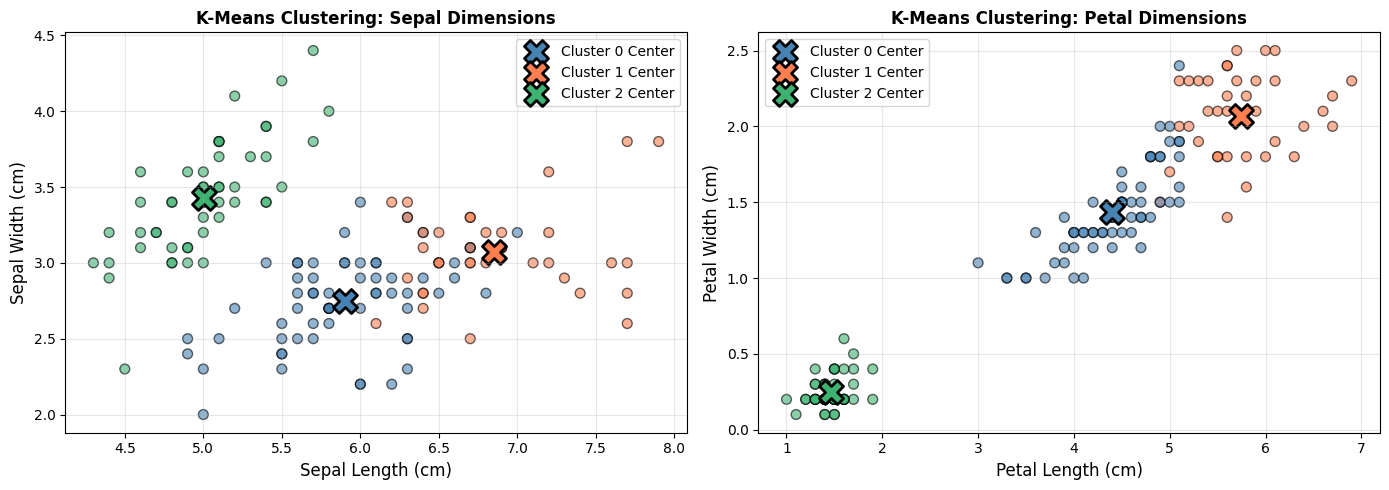

In [26]:
# Extract data for plotting
sepal_l = np.array(features_list[0])
sepal_w = np.array(features_list[1])
petal_l = np.array(features_list[2])
petal_w = np.array(features_list[3])

# Create scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Define colors for clusters
colors = ['steelblue', 'coral', 'mediumseagreen']
# Assign cluster color to each point
cluster_colors = [colors[label] for label in labels]

# Plot 1: Sepal dimensions
axes[0].scatter(sepal_l, sepal_w, c=cluster_colors, alpha=0.6, s=50, edgecolor='black')
for i in range(n_clusters):
    axes[0].scatter(kmeans.Means[i, 0], kmeans.Means[i, 1], 
                   c=colors[i], marker='X', s=300, edgecolor='black', linewidth=2,
                   label=f'Cluster {i} Center')
axes[0].set_xlabel('Sepal Length (cm)', fontsize=12)
axes[0].set_ylabel('Sepal Width (cm)', fontsize=12)
axes[0].set_title('K-Means Clustering: Sepal Dimensions', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Petal dimensions
axes[1].scatter(petal_l, petal_w, c=cluster_colors, alpha=0.6, s=50, edgecolor='black')
for i in range(n_clusters):
    axes[1].scatter(kmeans.Means[i, 2], kmeans.Means[i, 3], 
                   c=colors[i], marker='X', s=300, edgecolor='black', linewidth=2,
                   label=f'Cluster {i} Center')
axes[1].set_xlabel('Petal Length (cm)', fontsize=12)
axes[1].set_ylabel('Petal Width (cm)', fontsize=12)
axes[1].set_title('K-Means Clustering: Petal Dimensions', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Performance Comparison: Numerics vs Scikit-Learn

Let's compare speed and results with scikit-learn's K-Means.

**Note:** This requires scikit-learn to be installed.
```bash
pip install scikit-learn
```
Scikit-learn is the newer implementation of sklearn. In the cell below we call sklearn as the two packages are interchangeable. However, sklearn can no longer be installed directly and you must install scikit-learn.

If you don't have scikit-learn installed, skip this cell.

In [27]:
start = time.perf_counter()
kmeans_numerics = KMeans(features, n_clusters)
kmeans_numerics.Train(12345)
time_numerics = time.perf_counter() - start

X = pd.DataFrame({
    'Sepal Length': sepal_l,
    'Sepal Width': sepal_w,
    'Petal Length': petal_l,
    'Petal Width': petal_w
})

start = time.perf_counter()
kmeans_sklearn = SKLearnKMeans(n_clusters=n_clusters, init="k-means++", n_init=1, max_iter=1000, random_state=12345)
kmeans_sklearn.fit(X)
time_sklearn = time.perf_counter() - start

numerics_centers = np.array([[kmeans_numerics.Means[i, j] for j in range(4)] for i in range(n_clusters)])
sklearn_centers = kmeans_sklearn.cluster_centers_

# Match cluster labels
cost_matrix = np.linalg.norm(numerics_centers[:, None, :] - sklearn_centers[None, :, :], axis=2)
row_ind, col_ind = linear_sum_assignment(cost_matrix)

numerics_labels = list(kmeans_numerics.Labels)
sklearn_labels = kmeans_sklearn.labels_
numerics_counts = [numerics_labels.count(i) for i in range(n_clusters)]
sklearn_counts_matched = [sum(sklearn_labels == col_ind[i]) for i in range(n_clusters)]

perf_df = pd.DataFrame([
    ['KMeans', 'Numerics', time_numerics*1000],
    ['KMeans', 'scikit-learn', time_sklearn*1000],
], columns=['Model', 'Library', 'Runtime_ms'])
display(perf_df)
print(f"Speedup: Numerics is {time_sklearn/time_numerics:.2f}x faster than scikit-learn")

counts_df = pd.DataFrame({
    'Cluster': list(range(n_clusters)),
    'Numerics': numerics_counts,
    'Scikit-Learn': sklearn_counts_matched
})
display(counts_df)

center_dist = []
sklearn_centers_ordered = sklearn_centers[col_ind]
for i in range(n_clusters):
    distance = np.linalg.norm(numerics_centers[i] - sklearn_centers_ordered[i])
    center_dist.append(distance)
dist_df = pd.DataFrame({'Cluster': list(range(n_clusters)), 'CenterDistance': center_dist})
display(dist_df)

,Model,Library,Runtime_ms
0,KMeans,Numerics,0.5152
1,KMeans,scikit-learn,7.2250


Speedup: Numerics is 14.02x faster than scikit-learn


,Cluster,Numerics,Scikit-Learn
0,0,62,61
1,1,38,39
2,2,50,50


,Cluster,CenterDistance
0,0,2.011435e-02
1,1,3.217668e-02
2,2,1.408988e-15


### Example 2: Clustering Generated Data

Let's test K-Means on synthetic data with known clusters.

Running K-Means on synthetic data...


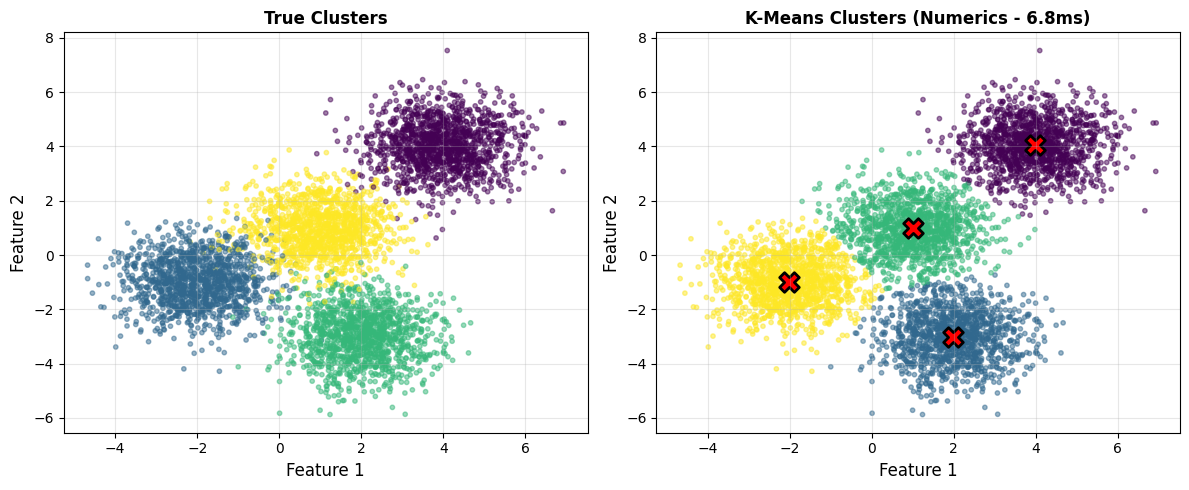


Successfully clustered 5000 points into 4 clusters
Runtime: 6.77 ms


In [28]:
# Generate synthetic data with 4 clear clusters
np.random.seed(12345)
X, y_true = make_blobs(n_samples=5000, centers=[[4,4], [-2, -1], [2, -3], [1, 1]], 
                        cluster_std=0.90)

# Convert to Numerics format (transpose: features as rows)
X_T = X.T
features_list_synthetic = List[Array[Double]]()
for row in X_T:
    net_row = Array[Double]([float(v) for v in row])
    features_list_synthetic.Add(net_row)

features_synthetic = Matrix(features_list_synthetic)

# Run Numerics K-Means
print("Running K-Means on synthetic data...")
start = time.perf_counter()
kmeans_synthetic = KMeans(features_synthetic, 4)
kmeans_synthetic.Train(12345)
time_numerics_synth = time.perf_counter() - start

labels_numerics = list(kmeans_synthetic.Labels)

# Visualize results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', alpha=0.5, s=10)
plt.title('True Clusters', fontsize=12, fontweight='bold')
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=labels_numerics, cmap='viridis', alpha=0.5, s=10)
for i in range(4):
    plt.scatter(kmeans_synthetic.Means[i, 0], kmeans_synthetic.Means[i, 1],
                marker='X', s=200, c='red', edgecolor='black', linewidth=2)
plt.title(f'K-Means Clusters (Numerics - {time_numerics_synth*1000:.1f}ms)', 
            fontsize=12, fontweight='bold')
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nSuccessfully clustered {len(labels_numerics)} points into 4 clusters")
print(f"Runtime: {time_numerics_synth*1000:.2f} ms")


## 2. Gaussian Mixture Models
Gaussian Mixture Models are probabilistic clustering methods that allow soft assignments (membership probabilities), unlike K-Means' hard labels. They're useful when cluster shapes are elliptical or overlapping.

GMM summary


,Metric,Value
0,Runtime (ms),17.484000
1,ARI,0.941012
2,Iterations,65.000000
3,Log-likelihood,140.370638


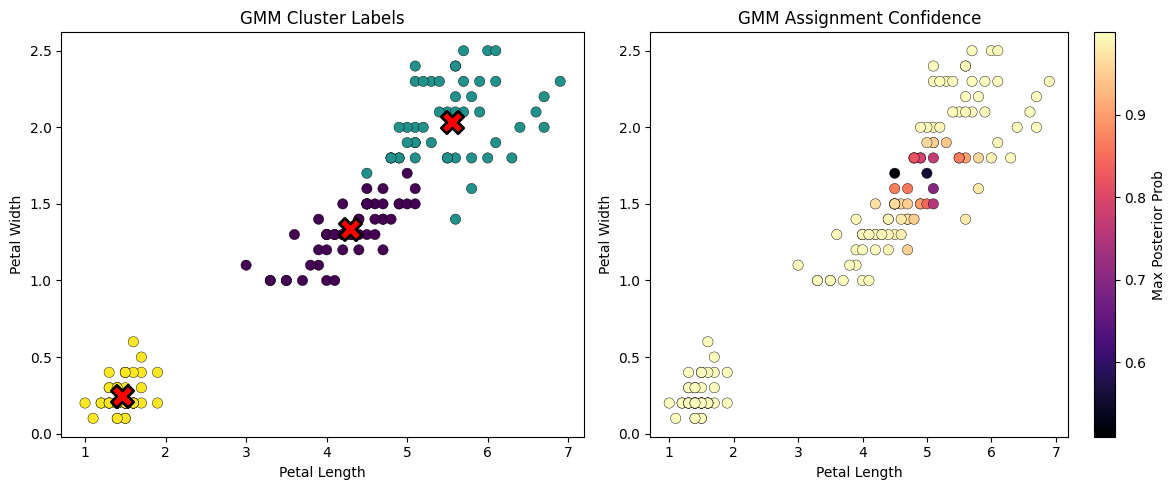

In [29]:
# Use iris dataset
X_gmm = X_iris[:, [2, 3]]
# Create mixture model
gmm = GaussianMixtureModel(convert_to_dotnet_2d_array(X_gmm), 3)
gmm.MaxIterations = 500
gmm.Tolerance = 1e-8

# Fit mixture model and pull out labels (i.e. clusters)
gmm_ms = timed_fit(lambda: gmm.Train(12345, True))
labels_gmm = np.array(list(gmm.Labels), dtype=int)
# sklearn Rand index adjusted for chance (computes similarity measure between two clusterings)
ari_gmm = adjusted_rand_score(y_iris, labels_gmm)

n, k = X_gmm.shape[0], 3
# Get likelihood for each data point(row) and for each cluster (column)
probs = np.array([[gmm.LikelihoodMatrix[i, j] for j in range(k)] for i in range(n)])
confidence = probs.max(axis=1)

gmm_tbl = pd.DataFrame({'Metric':['Runtime (ms)','ARI','Iterations','Log-likelihood'],'Value':
                        [gmm_ms,ari_gmm,gmm.Iterations,gmm.LogLikelihood]})
print('GMM summary')
display(gmm_tbl)

fig, ax = plt.subplots(1, 2, figsize=(12,5))
ax[0].scatter(X_gmm[:,0], X_gmm[:,1], c=labels_gmm, cmap='viridis', s=55, edgecolor='black', linewidth=0.3)
for i in range(3):
    ax[0].scatter(gmm.Means[i,0], gmm.Means[i,1], marker='X', s=260, c='red', edgecolor='black', linewidth=2)
ax[0].set_title('GMM Cluster Labels'); ax[0].set_xlabel('Petal Length'); ax[0].set_ylabel('Petal Width')

sc = ax[1].scatter(X_gmm[:,0], X_gmm[:,1], c=confidence, cmap='magma', s=55, edgecolor='black', linewidth=0.3)
ax[1].set_title('GMM Assignment Confidence'); ax[1].set_xlabel('Petal Length'); ax[1].set_ylabel('Petal Width')
plt.colorbar(sc, ax=ax[1], label='Max Posterior Prob')
plt.tight_layout(); plt.show()

results.append({'Algorithm':'Gaussian Mixture Model','Task':'Clustering','Metric_1':'ARI','Value_1':ari_gmm,'Metric_2':'Runtime (ms)','Value_2':gmm_ms})

## 3. K-Nearest Neighbors (KNN) 

### Classification
K-Nearest Neighbors predicts by looking at nearby training points, so it's simple and intuitive. Because it relies on distances, feature scaling is important.

KNN classification summary


,Metric,Value
0,Accuracy,0.977778
1,F1-macro,0.977143


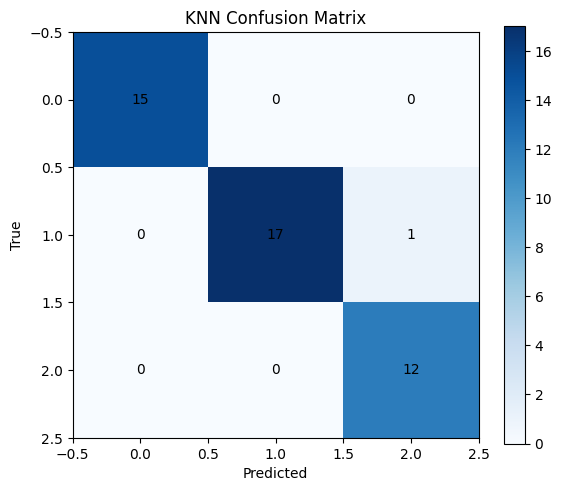

In [30]:
wine = load_wine()
X, y = wine.data, wine.target.astype(float)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Standardize by removing the mean and scaling to unit varaiance
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

X_train_net = convert_to_dotnet_2d_array(X_train_s)
y_train_net = convert_to_dotnet_array(y_train)
X_test_net = convert_to_dotnet_2d_array(X_test_s)

# Initialize
knn_clf = KNearestNeighbors(Matrix(X_train_net), Vector(y_train_net), 7)
knn_clf.IsRegression = False

y_pred = np.array(list(knn_clf.Predict(Matrix(X_test_net))), dtype=int)
# Performance metrics
acc = accuracy_score(y_test.astype(int), y_pred)
f1 = f1_score(y_test.astype(int), y_pred, average='macro')
cm = confusion_matrix(y_test, y_pred)

knn_cls_df = pd.DataFrame({'Metric':['Accuracy','F1-macro'],'Value':[acc, f1]})
print('KNN classification summary')
display(knn_cls_df)

# The diagonal represent correct classifications
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('True')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.colorbar(); plt.tight_layout(); plt.show()

results.append({'Algorithm':'KNN','Task':'Classification','Metric_1':'Accuracy','Value_1':acc,'Metric_2':'F1-macro','Value_2':f1})

### Regression
In regression mode, KNN averages neighbor target values to make predictions. It can capture nonlinear behavior, but may degrade in very high-dimensional settings.

Decision Tree Regression Summary


,Metric,Value
0,RMSE,54.898579
1,R²,0.454969


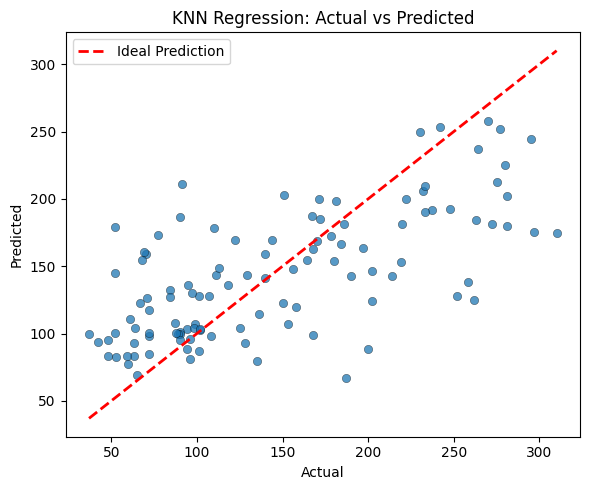

In [31]:
diab = load_diabetes()
X, y = diab.data, diab.target.astype(float)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Standardize by removing the mean and scaling to unit varaiance
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

X_train_net = convert_to_dotnet_2d_array(X_train_s)
y_train_net = convert_to_dotnet_array(y_train)
X_test_net = convert_to_dotnet_2d_array(X_test_s)

# Initialize
knn_reg = KNearestNeighbors(Matrix(X_train_net), Vector(y_train_net), 9)
knn_reg.IsRegression = True

y_pred = np.array(list(knn_reg.Predict(Matrix(X_test_net))), dtype=float)
# Performace metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

knn_rg_df = pd.DataFrame({'Metric':['RMSE','R²'],'Value':[rmse, r2]})
print('Decision Tree Regression Summary')
display(knn_rg_df)

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.75, edgecolor='black', linewidth=0.3)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', lw=2, label='Ideal Prediction')
plt.xlabel('Actual'); plt.ylabel('Predicted'); plt.title('KNN Regression: Actual vs Predicted'); plt.legend(); plt.tight_layout(); plt.show()

results.append({'Algorithm':'KNN','Task':'Regression','Metric_1':'RMSE','Value_1':rmse,'Metric_2':'R²','Value_2':r2})

## 4. Decision Trees
### Classification
Decision Trees split feature space into human-readable rules, making them highly interpretable. They can model nonlinear boundaries but may overfit without depth/split controls.

Decision Tree Classification Summary


,Metric,Value
0,Accuracy,0.923077
1,F1,0.937143
2,Runtime (ms),10629.110100


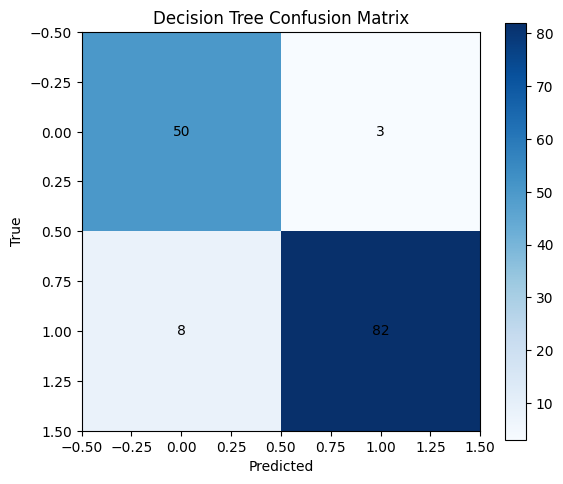

In [32]:
bc = load_breast_cancer()
X, y = bc.data, bc.target.astype(float)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

X_train_net = convert_to_dotnet_2d_array(X_train)
y_train_net = convert_to_dotnet_array(y_train)
X_test_net = convert_to_dotnet_2d_array(X_test)

# Intializie
dt_clf = DecisionTree(Matrix(X_train_net), Vector(y_train_net), 12345)
dt_clf.IsRegression = False
# Depth control is very important for decision trees
dt_clf.MaxDepth = 8
dt_clf.MinimumSplitSize = 5
dt_clf.Features = X_train.shape[1]

dt_clf_ms = timed_fit(lambda: dt_clf.Train())
y_pred = np.array(list(dt_clf.Predict(Matrix(X_test_net))), dtype=int)

# Performance metrics
acc = accuracy_score(y_test.astype(int), y_pred)
f1 = f1_score(y_test.astype(int), y_pred)
cm = confusion_matrix(y_test.astype(int), y_pred)

dt_cls_df = pd.DataFrame({'Metric':['Accuracy','F1','Runtime (ms)'],'Value':[acc,f1,dt_clf_ms]})
print('Decision Tree Classification Summary')
display(dt_cls_df)

# The diagonal represents correct classifications
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('True')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.colorbar(); plt.tight_layout(); plt.show()

results.append({'Algorithm':'Decision Tree','Task':'Classification','Metric_1':'Accuracy','Value_1':acc,'Metric_2':'Runtime (ms)','Value_2':dt_clf_ms})

### Regression
Regression trees predict continuous values by averaging outcomes in terminal leaves. They're flexible and easy to tune, but single trees are usually less stable than ensembles.

Decision Tree Regression Summary


,Metric,Value
0,RMSE,71.132731
1,R²,0.084964
2,Runtime (ms),81.742700


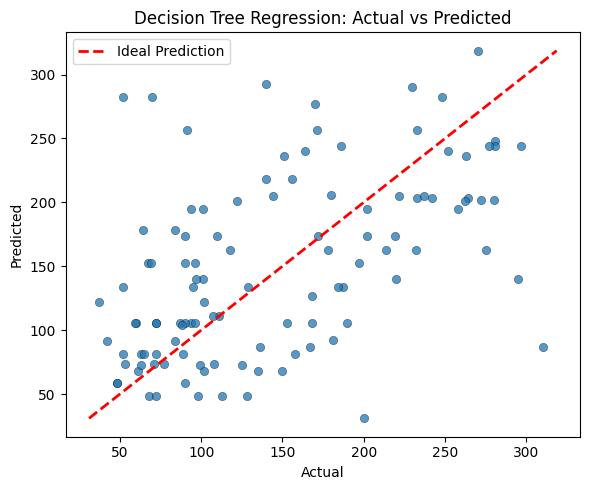

In [33]:
X, y = diab.data, diab.target.astype(float)
# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

X_train_net = convert_to_dotnet_2d_array(X_train)
y_train_net = convert_to_dotnet_array(y_train)
X_test_net = convert_to_dotnet_2d_array(X_test)

dt_reg = DecisionTree(Matrix(X_train_net), Vector(y_train_net), 12345)
# We have to ensure the Decision Tree regressor knows it's a regression task (not classification) since it can do both
dt_reg.IsRegression = True
# Max Depth helps control overfitting
dt_reg.MaxDepth = 8
# Minimum split size also helps control overfitting by preventing splits that are too small to be meaningful, and can speed up training
dt_reg.MinimumSplitSize = 8
dt_reg.Features = X_train.shape[1]

dt_reg_ms = timed_fit(lambda: dt_reg.Train())
y_pred = np.array(list(dt_reg.Predict(Matrix(X_test_net))), dtype=float)

# Performace metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

dt_rg_df = pd.DataFrame({'Metric':['RMSE','R²','Runtime (ms)'],'Value':[rmse,r2,dt_reg_ms]})
print('Decision Tree Regression Summary')
display(dt_rg_df)

results.append({
    "Algorithm": "Decision Tree",
    "Task": "Regression",
    "Metric_1": "RMSE",
    "Value_1": rmse,
    "Metric_2": "R²",
    "Value_2": r2
})

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.75, edgecolor="black", linewidth=0.3)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--", lw=2, label ="Ideal Prediction")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Decision Tree Regression: Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Random Forest
### Classification
Random Forest combines many trees trained on bootstrapped samples to improve robustness and reduce overfitting. It often gives strong default performance for tabular classification tasks.

Random Forest Classification Summary


,Metric,Value
0,Accuracy,0.461538
1,F1,0.252427
2,Runtime (s),24.813100


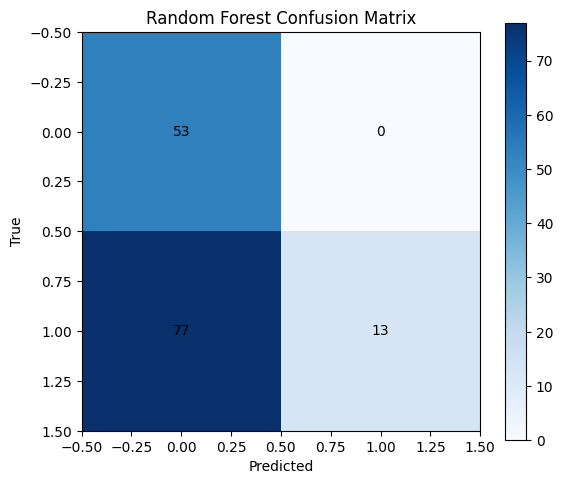

In [34]:
X, y = bc.data, bc.target.astype(float)
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

X_train_net = convert_to_dotnet_2d_array(X_train)
y_train_net = convert_to_dotnet_array(y_train)
X_test_net = convert_to_dotnet_2d_array(X_test)

# Initialize
rf_clf = RandomForest(Matrix(X_train_net), Vector(y_train_net), 12345)
rf_clf.IsRegression = False
rf_clf.NumberOfTrees = 300
rf_clf.MaxDepth = 20
rf_clf.MinimumSplitSize = 2
rf_clf.Features = int(np.sqrt(X_train.shape[1]))

rf_clf_ms = timed_fit(lambda: rf_clf.Train())
pred_raw = rf_clf.Predict(Matrix(X_test_net))
n = pred_raw.GetLength(0)
y_pred = np.array([pred_raw[i, 3] for i in range(n)], dtype=float)
y_pred = np.rint(y_pred).astype(int)

# Performace metrics
acc = accuracy_score(y_test.astype(int), y_pred)
f1 = f1_score(y_test.astype(int), y_pred)
cm = confusion_matrix(y_test.astype(int), y_pred)

rf_cls_df = pd.DataFrame({'Metric':['Accuracy','F1','Runtime (s)'],'Value':[acc,f1,rf_clf_ms/1000]})
print('Random Forest Classification Summary')
display(rf_cls_df)

# The diagonal shows correct classifications
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('True')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.colorbar(); plt.tight_layout(); plt.show()

results.append({'Algorithm':'Random Forest','Task':'Classification','Metric_1':'Accuracy','Value_1':acc,'Metric_2':'Runtime (ms)','Value_2':rf_clf_ms})

### Regression
In regression mode, Random Forest averages predictions across many trees, which generally improves stability and predictive power over a single tree. It's a strong baseline for nonlinear tabular regression.

Random Forest Classification Summary


,Metric,Value
0,RMSE,53.308046
1,R²,0.486093
2,Runtime (ms),943.904400


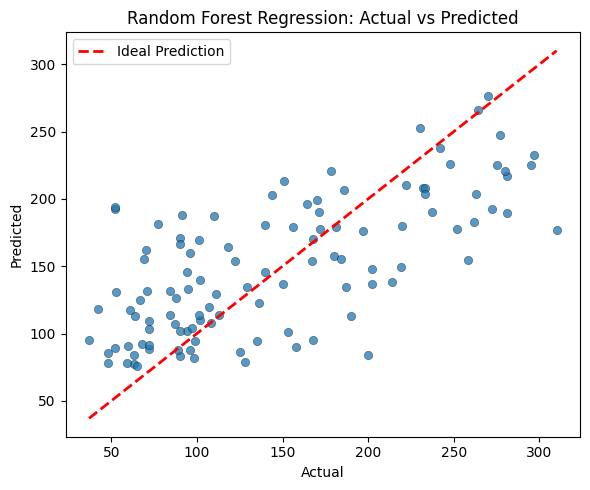

In [ ]:
X, y = diab.data, diab.target.astype(float)
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

X_train_net = convert_to_dotnet_2d_array(X_train)
y_train_net = convert_to_dotnet_array(y_train)
X_test_net = convert_to_dotnet_2d_array(X_test)

rf_reg = RandomForest(X_train_net, y_train_net, 12345)
# We have to ensure the Random Forest regressor knows it's a regression task (not classification) since it can do both
rf_reg.IsRegression = True
# More trees generally improves accuracy but increases runtime, 300 is a common default that balances well for many datasets
rf_reg.NumberOfTrees = 300
# Max Depth helps control overfitting
# Random Forests can often benefit from deeper trees than single Decision Trees since they average many trees
rf_reg.MaxDepth = 20
# Minimum split size also helps control overfitting by preventing splits that are too small to be meaningful, and can speed up training
rf_reg.MinimumSplitSize = 2
rf_reg.Features = max(1, X_train.shape[1] // 3)

rf_reg_ms = timed_fit(lambda: rf_reg.Train())

pred_raw = rf_reg.Predict(Matrix(X_test_net))
n = pred_raw.GetLength(0)
y_pred = np.array([pred_raw[i, 3] for i in range(n)], dtype=float)

# Performance metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

rf_reg_df = pd.DataFrame({'Metric':['RMSE','R²','Runtime (ms)'],'Value':[rmse,r2,rf_reg_ms]})
print('Random Forest Classification Summary')
display(rf_reg_df)


results.append({
    "Algorithm": "Random Forest",
    "Task": "Regression",
    "Metric_1": "RMSE",
    "Value_1": rmse,
    "Metric_2": "R²",
    "Value_2": r2
})

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.75, edgecolor="black", linewidth=0.3)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--", lw=2, label ="Ideal Prediction")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest Regression: Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Numerics vs scikit-learn Benchmarks
Now we compare our radom forest methods from Numerics with Python's implementations in the "scikit-learn" package.

In [36]:
benchmark_rows = []

# Classification benchmark
X, y = bc.data, bc.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
X_train_net = convert_to_dotnet_2d_array(X_train)
y_train_net = convert_to_dotnet_array(y_train.astype(float))
X_test_net = convert_to_dotnet_2d_array(X_test)

rf_num = RandomForest(X_train_net, y_train_net, 12345)
rf_num.IsRegression = False
rf_num.NumberOfTrees = 300
rf_num.Features = int(np.sqrt(X_train.shape[1]))

t_num = timed_fit(lambda: rf_num.Train())
pred_raw = rf_num.Predict(X_test_net)
n = pred_raw.GetLength(0)
y_num = np.array([pred_raw[i, 3] for i in range(n)], dtype=float)
y_num = np.rint(y_num).astype(int)
acc_num = accuracy_score(y_test, y_num)

t0 = time.perf_counter()
rf_sk = RandomForestClassifier(n_estimators=300, max_depth=100, random_state=12345, n_jobs=-1)
rf_sk.fit(X_train, y_train)
t_sk = (time.perf_counter() - t0) * 1000
acc_sk = accuracy_score(y_test, rf_sk.predict(X_test))

benchmark_rows.append(['RF Classifier', 'Numerics', t_num, acc_num])
benchmark_rows.append(['RF Classifier', 'scikit-learn', t_sk, acc_sk])

# Regression benchmark
X, y = diab.data, diab.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
X_train_net = convert_to_dotnet_2d_array(X_train)
y_train_net = convert_to_dotnet_array(y_train.astype(float))
X_test_net = convert_to_dotnet_2d_array(X_test)

rf_num_r = RandomForest(X_train_net, y_train_net, 12345)
rf_num_r.IsRegression = True
rf_num_r.NumberOfTrees = 300
rf_num_r.Features = max(1, X_train.shape[1] // 3)

t_num_r = timed_fit(lambda: rf_num_r.Train())
pred_raw = rf_num_r.Predict(X_test_net)
n = pred_raw.GetLength(0)
pred_num_r = np.array([pred_raw[i, 3] for i in range(n)], dtype=float)
r2_num = r2_score(y_test, pred_num_r)

t0 = time.perf_counter()
rf_sk_r = RandomForestRegressor(n_estimators=300, max_depth=100, random_state=12345, n_jobs=-1)
rf_sk_r.fit(X_train, y_train)
t_sk_r = (time.perf_counter() - t0) * 1000
r2_sk = r2_score(y_test, rf_sk_r.predict(X_test))

benchmark_rows.append(['RF Regressor', 'Numerics', t_num_r, r2_num])
benchmark_rows.append(['RF Regressor', 'scikit-learn', t_sk_r, r2_sk])

bench_df = pd.DataFrame(benchmark_rows, columns=['Model', 'Library', 'Runtime_ms', 'Score'])
display(bench_df)

,Model,Library,Runtime_ms,Score
0,RF Classifier,Numerics,30474.5025,0.461538
1,RF Classifier,scikit-learn,394.9072,0.958042
2,RF Regressor,Numerics,1479.7073,0.486586
3,RF Regressor,scikit-learn,254.2731,0.481694


## Summary
This notebook demonstrated end-to-end machine learning workflows with Numerics and compared them with familiar scikit-learn baselines.

You implemented and evaluated:

✓ K-Means clustering       
✓ Gaussian Mixture Models      
✓ K-Nearest Neighbors      
✓ Decision Trees       
✓ Random Forests (classification and regression)       

Primary evaluation metrics in this notebook include accuracy (classification), RMSE/R² (regression), and ARI-like clustering diagnostics where applicable.

## Exercise
1. Fit K Means with k=2.6 and plot inertia.
2. Compare GMM ARI with K-Means ARI.
3. Which method clusters Iris best?
